cuda
[[  43 -197 -150 ...  -73 -198   -5]
 [  36 -123 -141 ...  -51 -163  130]
 [  38   69   30 ...  -70 -244  -22]
 ...
 [  36 -124 -142 ...  -51 -158  128]
 [  58   26   49 ...  -40 -127  138]
 [  41 -198 -159 ...  -60 -127   57]]
[0. 0. 0. ... 0. 0. 1.]


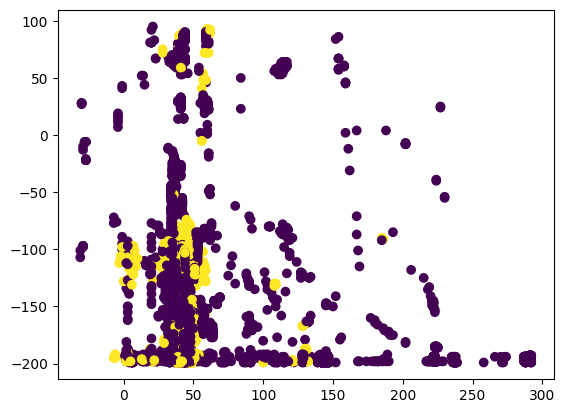

In [8]:
from kan import *
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

heart = fetch_ucirepo(id=75)
X = heart.data.features._values
y = heart.data.targets._values[:,0]
X, y = shuffle(X, y, random_state=42)

skf = StratifiedKFold(n_splits=5)


print(X)
print(y)
dtype = torch.get_default_dtype()
X_plot = torch.from_numpy(X).type(dtype).to(device)
y_plot = torch.from_numpy(y).type(dtype).to(device)
plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_plot[:].cpu().detach().numpy())
plt.show()

Params: 8064


description:   0%|                                                          | 0/350 [00:00<?, ?it/s]

| train_loss: 8.79e-02 | test_loss: 1.46e-01 | reg: 0.00e+00 | : 100%|█| 350/350 [00:10<00:00, 33.57
| train_loss: 6.83e-02 | test_loss: 1.74e-01 | reg: 0.00e+00 | : 100%|█| 350/350 [00:09<00:00, 35.89
| train_loss: 7.88e-02 | test_loss: 1.57e-01 | reg: 0.00e+00 | : 100%|█| 350/350 [00:09<00:00, 36.54
| train_loss: 8.12e-02 | test_loss: 2.20e-01 | reg: 0.00e+00 | : 100%|█| 350/350 [00:09<00:00, 37.38
| train_loss: 7.75e-02 | test_loss: 1.50e-01 | reg: 0.00e+00 | : 100%|█| 350/350 [00:09<00:00, 36.30


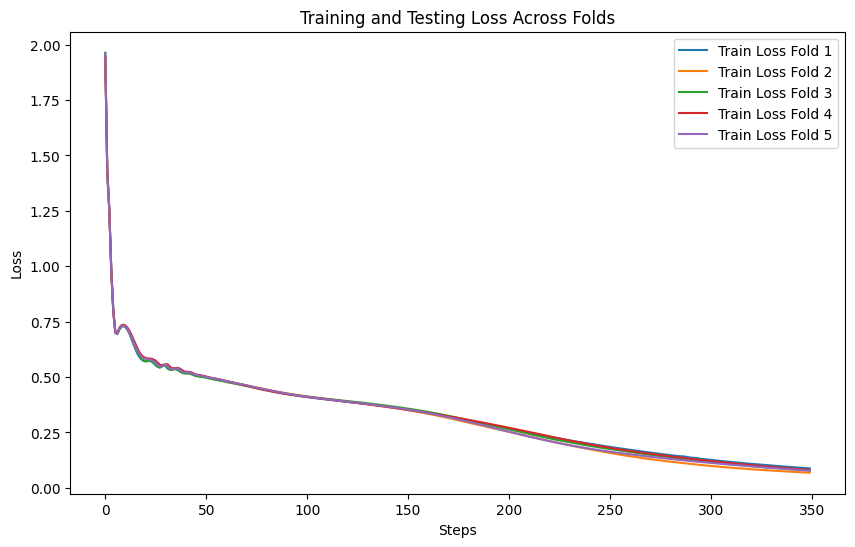

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
import time

dataset = {}
results = []

train_cms = []
test_cms = []

model = None

def train_acc_f():
    predictions = torch.argmax(model(dataset['train_input']), dim=1)
    return torch.mean((predictions == dataset['train_label']).type(dtype))
def test_acc_f():
    predictions = torch.argmax(model(dataset['test_input']), dim=1)
    return torch.mean((predictions == dataset['test_label']).type(dtype))

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='binary'),
        "recall": recall_score(y_true, y_pred, average='binary'),
        "f1_score": f1_score(y_true, y_pred, average='binary'),
        "fpr": fpr,
        "fnr": fnr
    }
    return metrics
#depth~3 too deep for this dataset
layer=6
KAN_width=[X.shape[1], layer, 2]
KAN_g=3
KAN_k=3
n_params = 0
for i in range(len(KAN_width)-1):
    n_params += KAN_width[i]*KAN_width[i+1]*(KAN_g+KAN_k+2)
print("Params:", n_params)

kan_train_metrics = []
kan_test_metrics = []
time_list=[]

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    dataset['train_input'] = torch.from_numpy(X[train_index]).type(torch.FloatTensor).to(device)
    dataset['test_input'] = torch.from_numpy(X[test_index]).type(torch.FloatTensor).to(device)
    dataset['train_label'] = torch.from_numpy(y[train_index]).type(torch.LongTensor).to(device)
    dataset['test_label'] = torch.from_numpy(y[test_index]).type(torch.LongTensor).to(device)

    model = KAN(width=KAN_width, grid=KAN_g, k=KAN_k, device=device, save_act=False, auto_save=False, seed=1)
    
    start_time = time.time()
    results.append(model.fit(dataset, opt="Adam", steps=350, loss_fn=torch.nn.CrossEntropyLoss(), lr=0.01))
    end_time = time.time()
    time_list.append(end_time - start_time)
    
    train_predictions = torch.argmax(model(dataset['train_input']), dim=1).cpu().numpy()
    test_predictions = torch.argmax(model(dataset['test_input']), dim=1).cpu().numpy()

    train_labels = dataset['train_label'].cpu().numpy()
    test_labels = dataset['test_label'].cpu().numpy()

    #metrics
    kan_train_metrics.append(compute_metrics(train_labels, train_predictions))
    kan_test_metrics.append(compute_metrics(test_labels, test_predictions))
    train_cms.append(confusion_matrix(train_labels, train_predictions))
    test_cms.append(confusion_matrix(test_labels, test_predictions))
    


plt.figure(figsize=(10, 6))

for i, result in enumerate(results):
    plt.plot(result['train_loss'], label=f'Train Loss Fold {i+1}')


plt.legend()
plt.ylabel('Loss')
plt.xlabel('Steps')
plt.title('Training and Testing Loss Across Folds')
plt.yscale('linear')
plt.show()

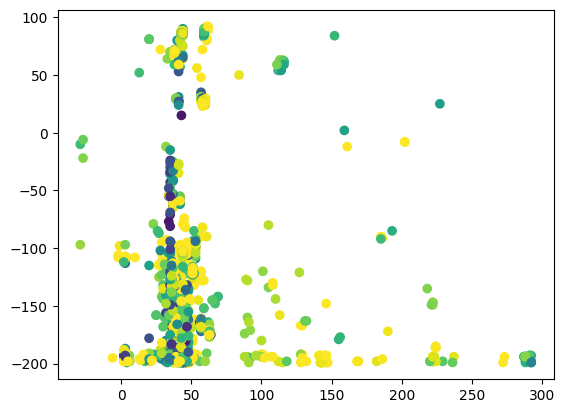

In [10]:
X_plot = dataset['test_input']
y_plot = model.forward(dataset['test_input'])[:, 1]
y_normalized = 1/(1 + np.exp(-y_plot.cpu().detach().numpy()))

plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_normalized)
plt.show()

Train Metrics:
accuracy: 0.9996 ± 0.0003
precision: 0.9990 ± 0.0005
recall: 0.9983 ± 0.0017
f1_score: 0.9986 ± 0.0010
fpr: 0.0002 ± 0.0001
fnr: 0.0017 ± 0.0017

Test Metrics:
accuracy: 0.9908 ± 0.0015
precision: 0.9752 ± 0.0062
recall: 0.9646 ± 0.0066
f1_score: 0.9698 ± 0.0049
fpr: 0.0045 ± 0.0011
fnr: 0.0354 ± 0.0066

Time Metrics: 9.7566 ± 0.3605


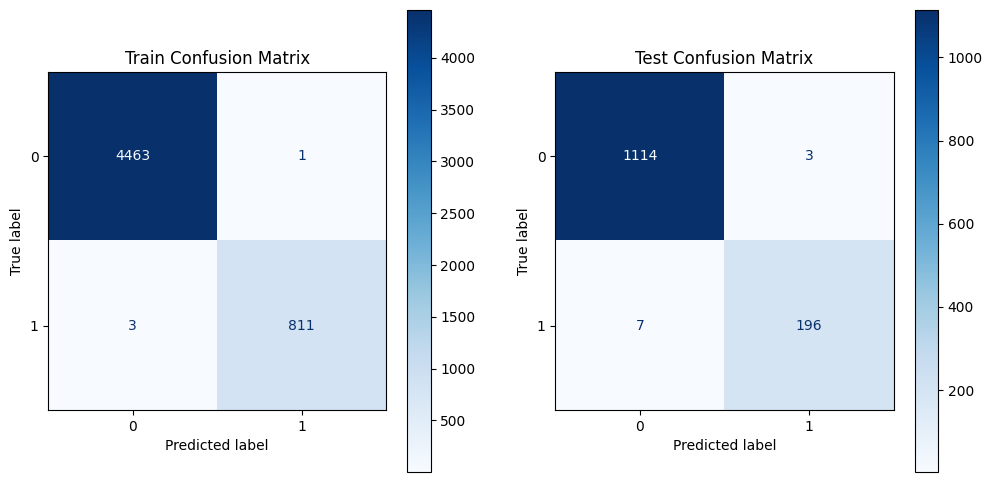

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np

def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated
def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated

train_metrics_summary = aggregate_metrics(kan_train_metrics)
test_metrics_summary = aggregate_metrics(kan_test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")

with open(f"KAN_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()

MLP

Params: 8065
Train Metrics: {'accuracy': {'mean': np.float64(0.9837449406124247), 'std': np.float64(0.003977156645850899)}, 'precision': {'mean': np.float64(0.9821839168988079), 'std': np.float64(0.009733291890462924)}, 'recall': {'mean': np.float64(0.9110093656219117), 'std': np.float64(0.018199484686213702)}, 'f1_score': {'mean': np.float64(0.9452157666642987), 'std': np.float64(0.013728820757966045)}, 'fpr': {'mean': np.float64(0.0030013205055649875), 'std': np.float64(0.0016312808059722856)}, 'fnr': {'mean': np.float64(0.08899063437808825), 'std': np.float64(0.01819948468621369)}}
Test Metrics: {'accuracy': {'mean': np.float64(0.9736283226503091), 'std': np.float64(0.002462980663449791)}, 'precision': {'mean': np.float64(0.9591810149806363), 'std': np.float64(0.020024019865178516)}, 'recall': {'mean': np.float64(0.8662754757075243), 'std': np.float64(0.009505227630256827)}, 'f1_score': {'mean': np.float64(0.9101814554872336), 'std': np.float64(0.007659411517450197)}, 'fpr': {'mean'

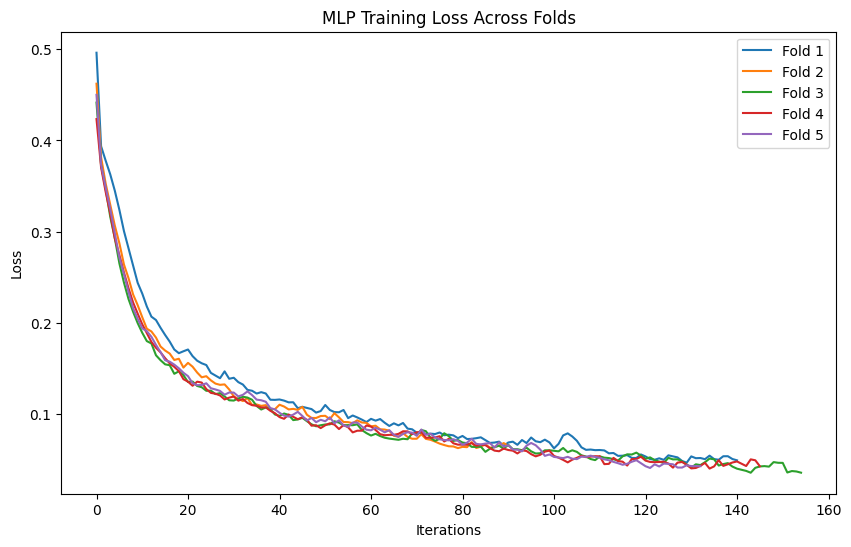

In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import time

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='binary'),
        "recall": recall_score(y_true, y_pred, average='binary'),
        "f1_score": f1_score(y_true, y_pred, average='binary'),
        "fpr": fpr,
        "fnr": fnr
    }
    return metrics

#depth>2 too deep for this dataset
leyer=48
hidden_layer_size = (leyer)
params=(X.shape[1], hidden_layer_size, 1)
n_params = 0
for i in range(len(params)-1):
    n_params += params[i]*params[i+1]+params[i+1]
print("Params:", n_params)

results = []
train_metrics = []
test_metrics = []
time_list=[]

y = y.cpu().detach().numpy() if isinstance(y, torch.Tensor) else y
for train_index, test_index in skf.split(X, y):
    train_input = X[train_index]
    train_label = y[train_index]
    test_input = X[test_index]
    test_label = y[test_index]
    
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_size, activation='logistic', solver='adam', max_iter=350)

    start_time = time.time()
    mlp.fit(train_input, train_label)
    end_time = time.time()
    time_list.append(end_time - start_time)

    train_predictions = mlp.predict(train_input)
    test_predictions = mlp.predict(test_input)

    results.append(mlp.loss_curve_)
    train_metrics.append(compute_metrics(train_label, train_predictions))
    test_metrics.append(compute_metrics(test_label, test_predictions))

train_metrics_summary = aggregate_metrics(train_metrics)
test_metrics_summary = aggregate_metrics(test_metrics)

print("Train Metrics:", train_metrics_summary)
print("Test Metrics:", test_metrics_summary)

plt.figure(figsize=(10, 6))
for i, loss_curve in enumerate(results):
    plt.plot(loss_curve, label=f'Fold {i+1}')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Across Folds')
plt.legend()
plt.show()

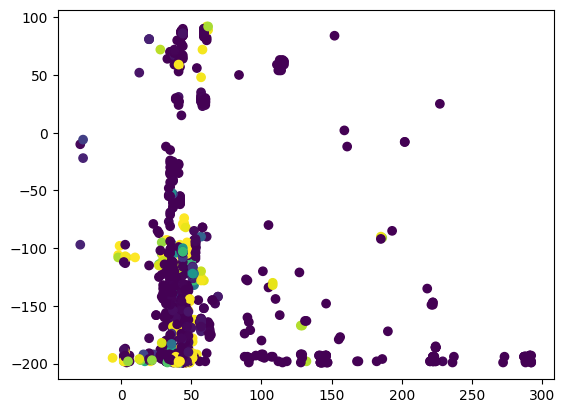

In [13]:
X_plot = dataset['test_input']
y_plot = mlp.predict_proba(dataset['test_input'].cpu().numpy())[:, 1]
plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_plot)
plt.show()

Train Metrics:
accuracy: 0.9837 ± 0.0040
precision: 0.9822 ± 0.0097
recall: 0.9110 ± 0.0182
f1_score: 0.9452 ± 0.0137
fpr: 0.0030 ± 0.0016
fnr: 0.0890 ± 0.0182

Test Metrics:
accuracy: 0.9736 ± 0.0025
precision: 0.9592 ± 0.0200
recall: 0.8663 ± 0.0095
f1_score: 0.9102 ± 0.0077
fpr: 0.0068 ± 0.0035
fnr: 0.1337 ± 0.0095

Time Metrics: 2.8241 ± 0.4920


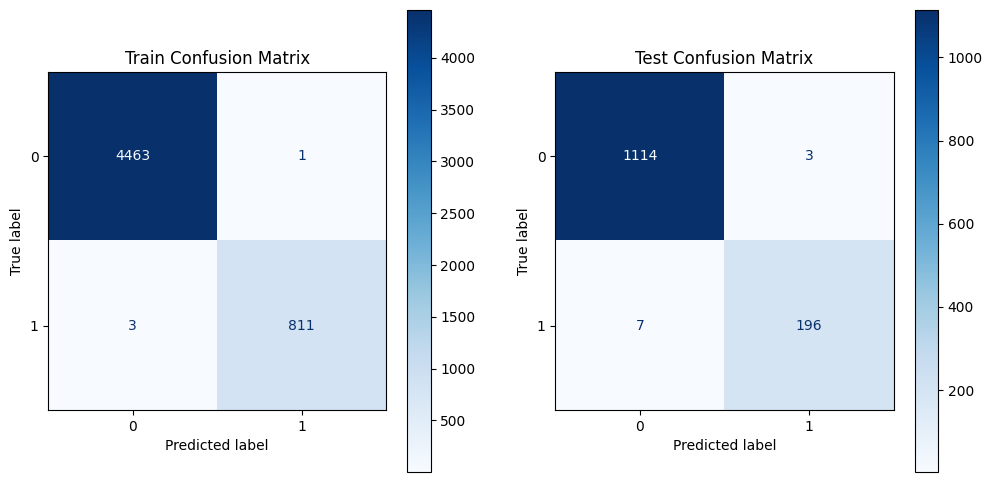

In [14]:
def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated

def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated


train_metrics_summary = aggregate_metrics(train_metrics)
test_metrics_summary = aggregate_metrics(test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")


with open(f"MLP_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()